In [31]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import GPT2Tokenizer, GPT2Model, logging

logging.set_verbosity_error()

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [33]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2");
model.to(device);
model.eval();

embeddings = model.wte.weight.detach().cpu()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [45]:
from typing import Tuple

def train_and_maximize_activation(
    seq_length: int,
    hidden_layer_idx: int,
    dim_idx: int,
    num_iterations: int = 1000,
    learning_rate: float = 0.01,
    l2_weight: float = 1e-3,
    device: torch.device = device
) -> Tuple[torch.Tensor, np.ndarray, np.ndarray]:

    model.eval()

    emb_std = model.wte.weight.detach().float().std().item()

    optimized_embeddings = torch.randn(
        (1, seq_length, embeddings.shape[1]),
        device=device,
        requires_grad=True
    )
    torch.nn.init.normal_(optimized_embeddings, mean=0.0, std=emb_std)

    optimizer = torch.optim.AdamW([optimized_embeddings], lr=learning_rate, weight_decay=0.0)

    activation_values = np.zeros(num_iterations, dtype=np.float32)
    gradient_norm = np.zeros(num_iterations, dtype=np.float32)

    for step in range(num_iterations):
        optimizer.zero_grad(set_to_none=True)

        outputs = model(
            inputs_embeds=optimized_embeddings,
            output_hidden_states=True,
            return_dict=True
        )

        hs = outputs.hidden_states[hidden_layer_idx]  # (1, seq, d_model)


        act = hs[0, :, dim_idx].mean()

        loss = -act + l2_weight * optimized_embeddings.pow(2).mean()
        loss.backward()

        grad = optimized_embeddings.grad
        gradient_norm[step] = grad.norm().item() if grad is not None else np.nan

        optimizer.step()
        activation_values[step] = act.detach().item()

    return optimized_embeddings.detach(), activation_values, gradient_norm


In [35]:
seq_length = 5
hidden_layer_idx = 10
dim_idx = 300
num_iterations = 1000
learning_rate = 0.01

out_embeddings, activation_values, gradient_norms = train_and_maximize_activation(seq_length, hidden_layer_idx, dim_idx, num_iterations=num_iterations, learning_rate=learning_rate)

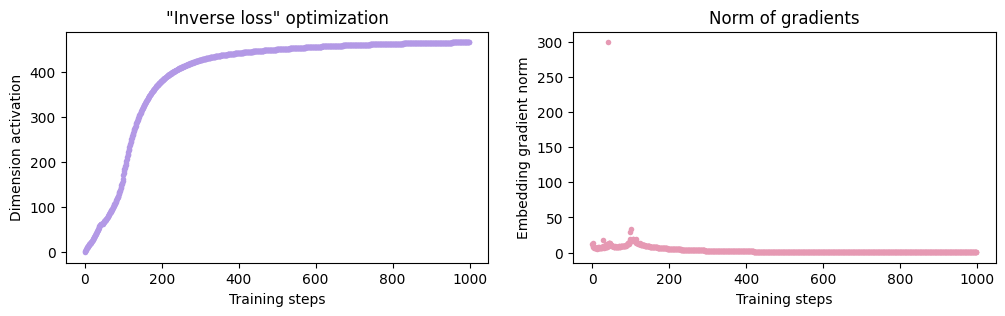

In [36]:
_, axs = plt.subplots(1, 2, figsize=(12, 3))

axs[0].plot(
    activation_values, "o",
    markersize=4,
    markerfacecolor=[.7, .6, .9],
    markeredgecolor="none"
)
axs[0].set(
    xlabel="Training steps",
    ylabel="Dimension activation",
    title='"Inverse loss" optimization'
)

axs[1].plot(
    gradient_norms, "o",
    markersize=4,
    markerfacecolor=[.9, .6, .7],
    markeredgecolor="none"
)
axs[1].set(
    xlabel="Training steps",
    ylabel="Embedding gradient norm",
    title="Norm of gradients"
)

plt.show()


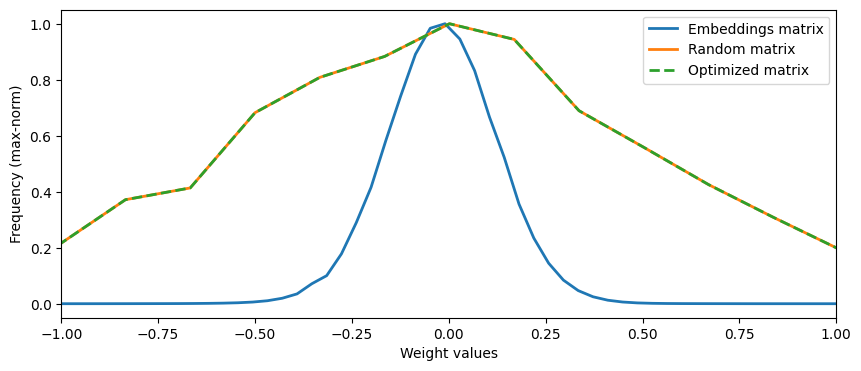

In [37]:
# get the histogram values
ye,xe = np.histogram(embeddings.flatten(),bins=80)
yo,xo = np.histogram(out_embeddings.flatten().detach().cpu(),bins=80)
yo2,xo2 = np.histogram(out_embeddings.flatten().detach().cpu(),bins=80)

plt.figure(figsize=(10,4))
plt.plot(xe[:-1],ye/np.max(ye),linewidth=2,label='Embeddings matrix')
plt.plot(xo[:-1],yo/np.max(yo),linewidth=2,label='Random matrix')
plt.plot(xo2[:-1],yo2/np.max(yo2),'--',linewidth=2,label='Optimized matrix')

plt.legend()
plt.gca().set(xlabel='Weight values',ylabel='Frequency (max-norm)',
              xlim=[-1,1])
plt.show()

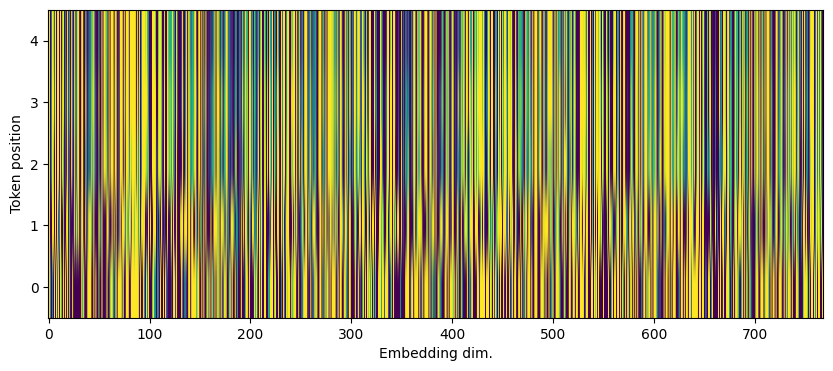

In [38]:
plt.figure(figsize=(10,4))
plt.imshow(out_embeddings.squeeze().detach().cpu(),
           aspect='auto',vmin=-.3,vmax=.3,origin='lower')

plt.gca().set(xlabel='Embedding dim.',ylabel='Token position')
plt.show()

# Find closest tokens

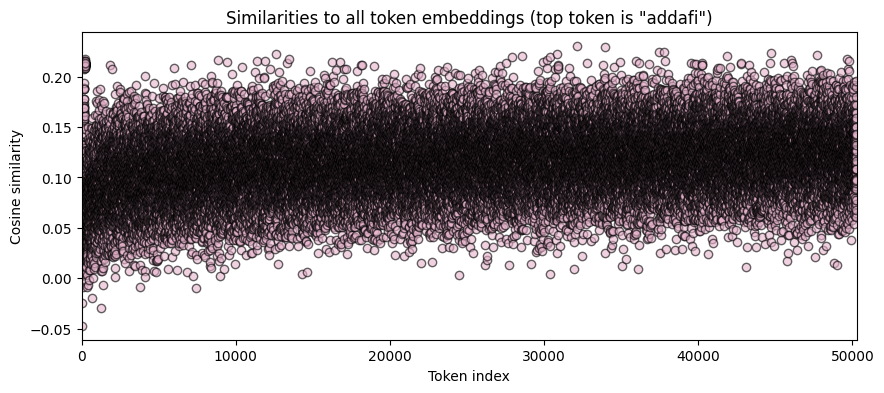

In [39]:
# one embed
oneemb = out_embeddings[0][0].detach().cpu()

# cosine similarity with all embedding vectors
cs = F.cosine_similarity(oneemb.unsqueeze(0), embeddings)

# find the token with max cossim
maxtok = np.argmax(cs)

# and visualize
plt.figure(figsize=(10,4))
plt.plot(cs,'ko',markerfacecolor=[.9,.7,.8,.6])
plt.gca().set(xlim=[-10,tokenizer.vocab_size+9],xlabel='Token index',ylabel='Cosine similarity',
              title=f'Similarities to all token embeddings (top token is "{tokenizer.decode(maxtok)}")')
plt.show()

In [40]:
# decode embeddings to closest tokens
optimized_tokens = []

for emb in out_embeddings[0]:

  # cosine similarity with embedding weights
  similarities = F.cosine_similarity(emb.unsqueeze(0).detach().cpu(), embeddings)

  # find the max similarity
  maxtok = np.argmax(similarities)
  optimized_tokens.append(maxtok)

print('Optimized token sequence:\n',tokenizer.decode(optimized_tokens, skip_special_tokens=False))

Optimized token sequence:
 addafi chimpan epidem epidem epidem


In [47]:
num_runs = 10
all_optimized_tokens = torch.zeros((num_runs, seq_length), dtype=int)

seq_length = 5
hidden_layer_idx = 10
dim_idx = 300
num_iterations = 1000
learning_rate = 0.01

for run in range(num_runs):
  out_embeddings, _, _ = train_and_maximize_activation(seq_length, hidden_layer_idx, dim_idx, num_iterations=num_iterations, learning_rate=learning_rate, device=device)

  for embi, emb in enumerate(out_embeddings[0]):

    # cosine similarities
    similarities = F.cosine_similarity(emb.unsqueeze(0).detach().cpu(), embeddings)

    # find the max similarity
    maxtok = np.argmax(similarities)
    all_optimized_tokens[run,embi] = maxtok

  print(f'Completed run {run+1} of {num_runs}')


Completed run 1 of 10
Completed run 2 of 10
Completed run 3 of 10
Completed run 4 of 10
Completed run 5 of 10
Completed run 6 of 10
Completed run 7 of 10
Completed run 8 of 10
Completed run 9 of 10
Completed run 10 of 10


In [49]:
unique_tokens, counts = np.unique(all_optimized_tokens.flatten(), return_counts=True)
print(f'{len(unique_tokens)}/{np.prod(all_optimized_tokens.shape)} tokens are unique')

for tok, cnt in zip(unique_tokens, counts):
  print(f'{cnt:2} optimization for token "{tokenizer.decode([tok])}"')

25/50 tokens are unique
 1 optimization for token "�"
 3 optimization for token "�"
 1 optimization for token " negoti"
 1 optimization for token " Spain"
 1 optimization for token " tiss"
 1 optimization for token " ethnic"
14 optimization for token " subur"
 2 optimization for token " teaspoon"
 1 optimization for token " bloc"
 3 optimization for token " epidem"
 1 optimization for token " lifelong"
 1 optimization for token " disagreed"
 1 optimization for token " hardship"
 1 optimization for token " Fem"
 4 optimization for token " superficial"
 1 optimization for token " Municipal"
 2 optimization for token "=~=~"
 2 optimization for token "shapeshifter"
 2 optimization for token " prudent"
 1 optimization for token " disagrees"
 2 optimization for token "oreAnd"
 1 optimization for token " Burma"
 1 optimization for token " biochemical"
 1 optimization for token "Keefe"
 1 optimization for token "omial"
